In [51]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import yaml
import importlib

import spline_new as spline
from scipy.integrate import simpson

### Plot normalized n(z) for the parameters entered in the corresponding .yml file

In [52]:
# import the corresponding .npz file according the parameters in the yaml file

# open yaml file
config_path = 'params_s19a-hz-nocalib.yml'
# config_path = 'params_pdr3-bao-wl-size.yml'
with open(config_path, 'r') as f:
    params = yaml.safe_load(f)

# import parameters to compute the corresponding file name and write the corresponding legend
version = params['nz']['version']
hsc_catalog = params['data']['hsc_catalog']
stem = params['data']['desi_data_release']
scale_cut = params['nz']['scale_cut']
tomo_bins = params['nz']['tomo_bins']
# tomo_bins=[]
corrections = params['nz']['corrections']
bounds = params['nz']['bounds']
# bounds = {5:[0.8,2.5], 6:[1.5,3.2], 7:[2.0,3.5]}
# bounds = {5:[0.0,3.5], 6:[0.0,3.5], 7:[0.0,3.5]}
tomo_to_tracer = params['nz']['tomo_to_tracer']
patches = params['nz']['areas']
imag_cut = params['nz']['imag_cut']

# compute the file name according to parameters
tracers = []
order = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
for tomo in tomo_bins:
    for tracer in tomo_to_tracer[tomo]:
        if tracer not in tracers:
            tracers.append(tracer)
tracers = sorted(tracers, key=order.index)

if params['nz']['title'] != "":
    title = f"{params['nz']['title']}_"
    title_plot = f"{params['nz']['title']}"
else:
    title = ""
    title_plot = None

identifier = f'mocs={"".join(map(str, patches))}_icut={imag_cut}'

names_bis = {
    'npz_cross': 'w/o correction', 
    'npz_bs': 'w/ spectro. bias', 
    'npz_bs_bp': 'w/ spectro. & photo. bias', 
    'npz_bs_bp_mag': 'w/ spectro., photo. & mag. corrections'
}

# load the corresponding .npz file
npz_filename = (
    f'nz_results/{title}nz_tracers={",".join(tracers)}_'
    f'bins={"".join(map(str, tomo_bins))}_scale_cut={scale_cut[0]}-{scale_cut[1]}_'
    f'{identifier}_{stem}_{hsc_catalog}_{version}.npz'
)

tbl = np.load(npz_filename)
norm_tbl = {}

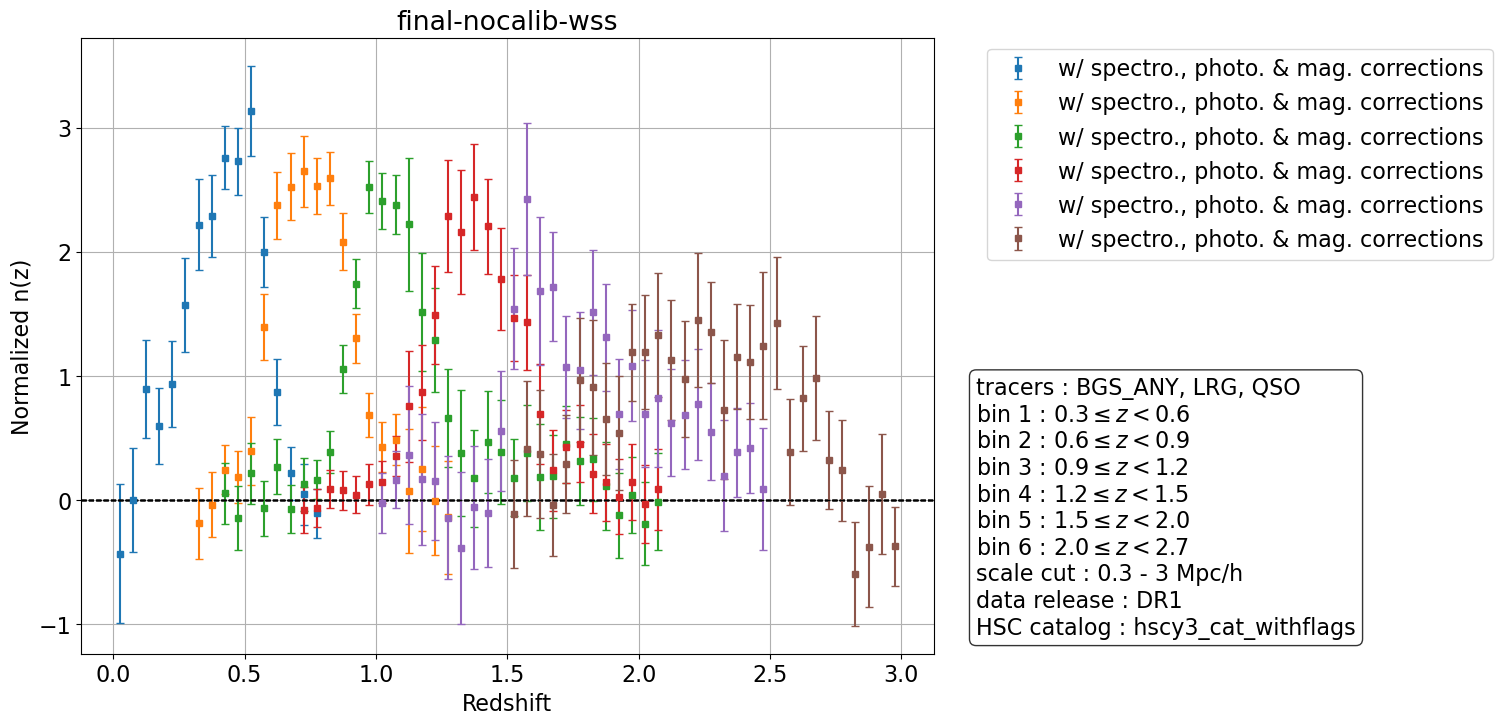

In [53]:
# plot normalized n(z) distribution
plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(figsize=(11, 8))

for tomo in tomo_bins:
    for i, na in enumerate(corrections):
        zn = tbl[f'{tomo}/{na}_z']
        z_mask = (zn >= bounds[tomo][0]) & (zn <= bounds[tomo][1])
        
        np_z = tbl[f'{tomo}/{na}'][z_mask]
        np_z_err = tbl[f'{tomo}/{na}_err'][z_mask]
        
        amplitude = np.trapz(np_z, zn[z_mask])
        
        norm_tbl[f'{tomo}/{na}_z'] = zn[z_mask]
        norm_tbl[f'{tomo}/{na}'] = np_z / amplitude
        norm_tbl[f'{tomo}/{na}_err'] = np_z_err / amplitude
        
        plt.errorbar(
            zn[z_mask],
            norm_tbl[f'{tomo}/{na}'],
            norm_tbl[f'{tomo}/{na}_err'],
            capsize=3,
            label=f'{names_bis[corrections[i]]}',
            linestyle='',
            marker='s',
            ms=4,
        )
        
    plt.axhline(0, color='k', linestyle='--', linewidth=1)
    plt.grid(True)
    plt.xlabel('Redshift')
    plt.ylabel('Normalized n(z)')

# text and legend
lines = []
for tomo in tomo_bins:
    low = params['bins']['hsc'][tomo][0]
    high = params['bins']['hsc'][tomo][1]
    lines.append(f"bin {tomo} : ${low} \\leq z < {high}$")

text = "\n".join([
    f"tracers : {', '.join(tracers)}",
    *lines,
    f"scale cut : {scale_cut[0]} - {scale_cut[1]} Mpc/h",
    f"data release : DR{stem[2:]}",
    f"HSC catalog : {hsc_catalog}"
])
plt.text(1.05, 0.45, text, transform=plt.gca().transAxes, ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
# plt.text(0.6, 0.2, text, transform=plt.gca().transAxes, ha='left', va='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# plt.legend(loc='upper right')

title_plot = title_plot
plt.title(title_plot)

# save .png file in the 'figs/' folder
suffix = (
    f'{title}nz_tracers={",".join(tracers)}_'
    f'bins={"".join(map(str, tomo_bins))}_scale_cut={scale_cut[0]}-{scale_cut[1]}_'
    f'{identifier}_{stem}_{hsc_catalog}_{version}'
)

Path('figs').mkdir(parents=True, exist_ok=True)
plt.savefig(f'figs/{suffix}.png', bbox_inches='tight', dpi=300)

plt.show()

### Splines

In [56]:
# import the corresponding .npz file according the parameters in the yaml file

# open yaml file
config_path = 'params_s19a-hz-nocalib.yml'
with open(config_path, 'r') as f:
    params = yaml.safe_load(f)

from config import CorrelationConfig
config = CorrelationConfig.load(config_path)
import combination_new as comb

# import parameters to compute the corresponding file name and write the corresponding legend
version = params['nz_splines']['version']
hsc_catalog = params['data']['hsc_catalog']
stem = params['data']['desi_data_release']
scale_cut = params['nz_splines']['scale_cut']
tomo_bins = params['nz_splines']['tomo_bins']
corrections = params['nz_splines']['corrections']
tomo_to_tracer = params['nz_splines']['tomo_to_tracer']
patches = params['nz_splines']['areas']
imag_cut = params['nz_splines']['imag_cut']

z_all = np.linspace(0, 3, 1000)
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]
name_to_label = {
    "npz_cross": "No bias evolution",
    "npz_bs": r"$b_s(z)$",
    "npz_bs_bp": r"$b_s(z), b_p(z)$",
    "npz_bs_bp_mag": r"$b_s(z), b_p(z), \mu$",
}

tracers = []
order = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
    
title = params['nz_splines']['title']
if title != "":
    title += "_"

identifier = f'mocs={"".join(map(str, patches))}_icut={imag_cut}'

hsc_bins = params['bins']['hsc']

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG_bin=1_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG_bin=1_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG_bin=1_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG_bin=1_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=BGS_ANY,LRG_bin=1_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_b

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[0.02702703 0.03003003 0.03303303 0.03603604 0.03903904 0.04204204
 0.04504505 0.04804805 0.05105105 0.05405405 0.05705706 0.06006006
 0.06306306 0.06606607 0.06906907 0.07207207 0.07507508 0.07807808
 0.08108108 0.08408408 0.08708709 0.09009009 0.09309309 0.0960961
 0.0990991  0.1021021  0.10510511 0.10810811 0.11111111 0.11411411
 0.11711712 0.12012012 0.12312312 0.12612613 0.12912913 0.13213213
 0.13513514 0.13813814 0.14114114 0.14414414 0.14714715 0.15015015
 0.15315315 0.15615616 0.15915916 0.16216216 0.16516517 0.16816817
 0.17117117 0.17417417 0.17717718 0.18018018 0.18318318 0.18618619
 0.18918919 0.19219219 0.1951952  0.1981982  0.2012012  0.2042042
 0.20720721 0.21021021 0.21321321 0.21621622 0.21921922 0.22222222
 0.22522523 0.22822823 0.23123123 0.23423423 0.23723724 0.24024024
 0.24324324 0.24624625 0.24924925 0.25225225 0.25525526 0.25825826
 0.26126126 0.26426426 0.26726727 0.27027027 0.27327



Expectation
16th, 50th, 84th percentiles: [0.44881635 0.45600304 0.46324098]
Expectation from mean n(z): 0.45601567241107155




Expectation
16th, 50th, 84th percentiles: [0.42478881 0.43316825 0.44095041]
Expectation from mean n(z): 0.4330008609186944




Expectation
16th, 50th, 84th percentiles: [0.41369332 0.42226426 0.43062611]
Expectation from mean n(z): 0.42219895326722334




Expectation
16th, 50th, 84th percentiles: [0.41067934 0.4193051  0.42787399]
Expectation from mean n(z): 0.4192911502205357




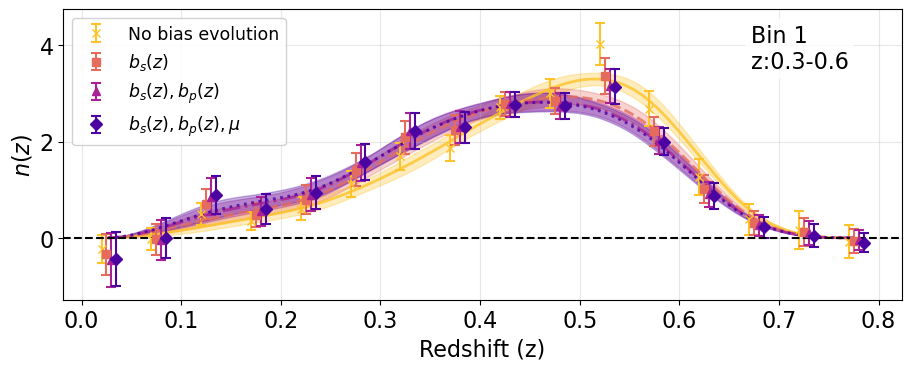

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=2_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=2_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=2_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=2_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=BGS_ANY,LRG,QSO_bin=2_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[0.32732733 0.33033033 0.33333333 0.33633634 0.33933934 0.34234234
 0.34534535 0.34834835 0.35135135 0.35435435 0.35735736 0.36036036
 0.36336336 0.36636637 0.36936937 0.37237237 0.37537538 0.37837838
 0.38138138 0.38438438 0.38738739 0.39039039 0.39339339 0.3963964
 0.3993994  0.4024024  0.40540541 0.40840841 0.41141141 0.41441441
 0.41741742 0.42042042 0.42342342 0.42642643 0.42942943 0.43243243
 0.43543544 0.43843844 0.44144144 0.44444444 0.44744745 0.45045045
 0.45345345 0.45645646 0.45945946 0.46246246 0.46546547 0.46846847
 0.47147147 0.47447447 0.47747748 0.48048048 0.48348348 0.48648649
 0.48948949 0.49249249 0.4954955  0.4984985  0.5015015  0.5045045
 0.50750751 0.51051051 0.51351351 0.51651652 0.51951952 0.52252252
 0.52552553 0.52852853 0.53153153 0.53453453 0.53753754 0.54054054
 0.54354354 0.54654655 0.54954955 0.55255255 0.55555556 0.55855856
 0.56156156 0.56456456 0.56756757 0.57057057 0.57357



Expectation
16th, 50th, 84th percentiles: [0.77266052 0.78092729 0.78930703]
Expectation from mean n(z): 0.780954745934229




Expectation
16th, 50th, 84th percentiles: [0.70946536 0.71574625 0.72225595]
Expectation from mean n(z): 0.7158347725944532




Expectation
16th, 50th, 84th percentiles: [0.70253848 0.70887321 0.71506688]
Expectation from mean n(z): 0.7087805402834726




Expectation
16th, 50th, 84th percentiles: [0.70393187 0.71070668 0.71772054]
Expectation from mean n(z): 0.7107524279367438




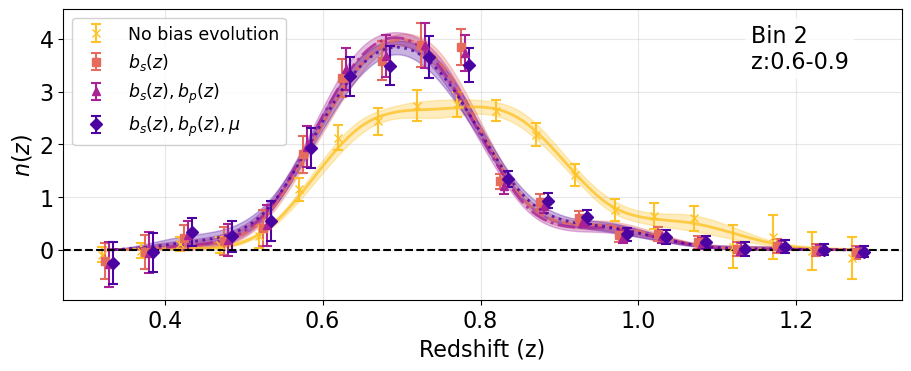

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=LRG,QSO_bin=3_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=LRG,QSO_bin=3_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=LRG,QSO_bin=3_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=LRG,QSO_bin=3_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=LRG,QSO_bin=3_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_bp_tracers=LRG,QSO

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[0.42642643 0.42942943 0.43243243 0.43543544 0.43843844 0.44144144
 0.44444444 0.44744745 0.45045045 0.45345345 0.45645646 0.45945946
 0.46246246 0.46546547 0.46846847 0.47147147 0.47447447 0.47747748
 0.48048048 0.48348348 0.48648649 0.48948949 0.49249249 0.4954955
 0.4984985  0.5015015  0.5045045  0.50750751 0.51051051 0.51351351
 0.51651652 0.51951952 0.52252252 0.52552553 0.52852853 0.53153153
 0.53453453 0.53753754 0.54054054 0.54354354 0.54654655 0.54954955
 0.55255255 0.55555556 0.55855856 0.56156156 0.56456456 0.56756757
 0.57057057 0.57357357 0.57657658 0.57957958 0.58258258 0.58558559
 0.58858859 0.59159159 0.59459459 0.5975976  0.6006006  0.6036036
 0.60660661 0.60960961 0.61261261 0.61561562 0.61861862 0.62162162
 0.62462462 0.62762763 0.63063063 0.63363363 0.63663664 0.63963964
 0.64264264 0.64564565 0.64864865 0.65165165 0.65465465 0.65765766
 0.66066066 0.66366366 0.66666667 0.66966967 0.67267



Expectation
16th, 50th, 84th percentiles: [1.12253786 1.14807504 1.17458747]
Expectation from mean n(z): 1.1484070317084378




Expectation
16th, 50th, 84th percentiles: [1.05766783 1.08194422 1.10561449]
Expectation from mean n(z): 1.081565509948576




Expectation
16th, 50th, 84th percentiles: [1.03898589 1.06077873 1.08335792]
Expectation from mean n(z): 1.0608021377999006




Expectation
16th, 50th, 84th percentiles: [1.01308441 1.03971069 1.06500599]
Expectation from mean n(z): 1.0391762900704409




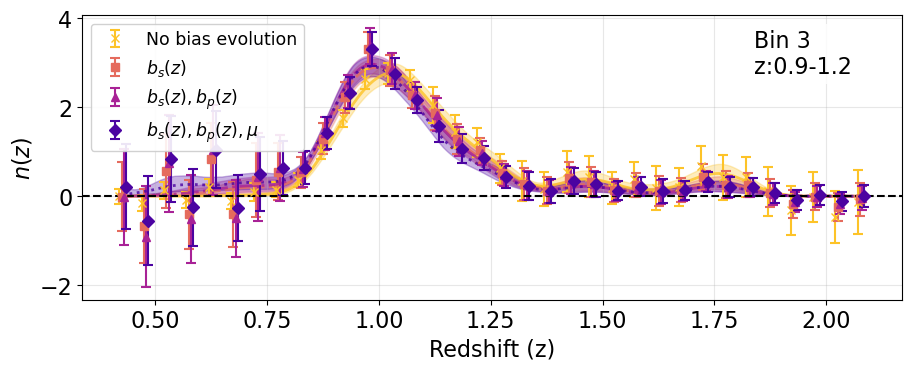

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=LRG,QSO_bin=4_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=LRG,QSO_bin=4_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=LRG,QSO_bin=4_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=LRG,QSO_bin=4_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=LRG,QSO_bin=4_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_bp_tracers=LRG,QSO

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[0.72672673 0.72972973 0.73273273 0.73573574 0.73873874 0.74174174
 0.74474474 0.74774775 0.75075075 0.75375375 0.75675676 0.75975976
 0.76276276 0.76576577 0.76876877 0.77177177 0.77477477 0.77777778
 0.78078078 0.78378378 0.78678679 0.78978979 0.79279279 0.7957958
 0.7987988  0.8018018  0.8048048  0.80780781 0.81081081 0.81381381
 0.81681682 0.81981982 0.82282282 0.82582583 0.82882883 0.83183183
 0.83483483 0.83783784 0.84084084 0.84384384 0.84684685 0.84984985
 0.85285285 0.85585586 0.85885886 0.86186186 0.86486486 0.86786787
 0.87087087 0.87387387 0.87687688 0.87987988 0.88288288 0.88588589
 0.88888889 0.89189189 0.89489489 0.8978979  0.9009009  0.9039039
 0.90690691 0.90990991 0.91291291 0.91591592 0.91891892 0.92192192
 0.92492492 0.92792793 0.93093093 0.93393393 0.93693694 0.93993994
 0.94294294 0.94594595 0.94894895 0.95195195 0.95495495 0.95795796
 0.96096096 0.96396396 0.96696697 0.96996997 0.97297



Expectation
16th, 50th, 84th percentiles: [1.40242291 1.41769008 1.43368697]
Expectation from mean n(z): 1.4181635085252093




Expectation
16th, 50th, 84th percentiles: [1.3785055  1.39425506 1.41057132]
Expectation from mean n(z): 1.3945252215912443




Expectation
16th, 50th, 84th percentiles: [1.36620664 1.38207246 1.39784745]
Expectation from mean n(z): 1.3819779070256963




Expectation
16th, 50th, 84th percentiles: [1.365113   1.38310299 1.40096238]
Expectation from mean n(z): 1.3830767626241778




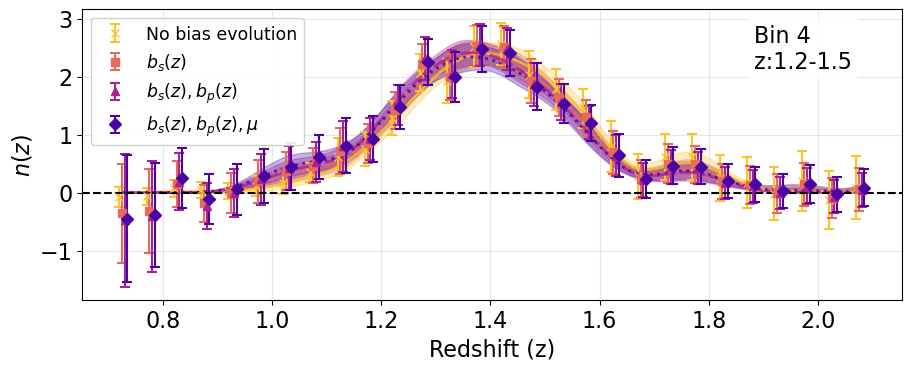

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=5_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=5_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=5_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=5_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=BGS_ANY,LRG,QSO_bin=5_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[1.02702703 1.03003003 1.03303303 1.03603604 1.03903904 1.04204204
 1.04504505 1.04804805 1.05105105 1.05405405 1.05705706 1.06006006
 1.06306306 1.06606607 1.06906907 1.07207207 1.07507508 1.07807808
 1.08108108 1.08408408 1.08708709 1.09009009 1.09309309 1.0960961
 1.0990991  1.1021021  1.10510511 1.10810811 1.11111111 1.11411411
 1.11711712 1.12012012 1.12312312 1.12612613 1.12912913 1.13213213
 1.13513514 1.13813814 1.14114114 1.14414414 1.14714715 1.15015015
 1.15315315 1.15615616 1.15915916 1.16216216 1.16516517 1.16816817
 1.17117117 1.17417417 1.17717718 1.18018018 1.18318318 1.18618619
 1.18918919 1.19219219 1.1951952  1.1981982  1.2012012  1.2042042
 1.20720721 1.21021021 1.21321321 1.21621622 1.21921922 1.22222222
 1.22522523 1.22822823 1.23123123 1.23423423 1.23723724 1.24024024
 1.24324324 1.24624625 1.24924925 1.25225225 1.25525526 1.25825826
 1.26126126 1.26426426 1.26726727 1.27027027 1.27327



Expectation
16th, 50th, 84th percentiles: [1.85293007 1.88203156 1.91063623]
Expectation from mean n(z): 1.8815932761362757




Expectation
16th, 50th, 84th percentiles: [1.80873536 1.83722254 1.86498892]
Expectation from mean n(z): 1.8366987064670584




Expectation
16th, 50th, 84th percentiles: [1.78351619 1.81238915 1.83938096]
Expectation from mean n(z): 1.811522413533115




Expectation
16th, 50th, 84th percentiles: [1.77885621 1.8091059  1.8393811 ]
Expectation from mean n(z): 1.8088104148558632




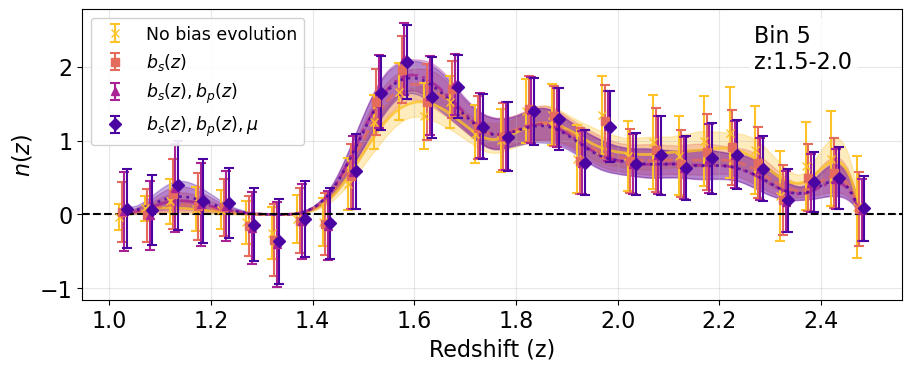

PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=6_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_cross_tracers=BGS_ANY,LRG,QSO_bin=6_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=6_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results/final-nocalib_npz_bs_tracers=BGS_ANY,LRG,QSO_bin=6_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: splines_results/final-nocalib_npz_bs_bp_tracers=BGS_ANY,LRG,QSO_bin=6_scale_cut=0.3-3_mocs=1234_icut=None_dr1_hscy3_cat_withflags_vF.nc
  - Metadata: splines_results

/tmp/ipykernel_1919836/3389670699.py:44: DeprecationWarning: You are passing x=[1.52552553 1.52852853 1.53153153 1.53453453 1.53753754 1.54054054
 1.54354354 1.54654655 1.54954955 1.55255255 1.55555556 1.55855856
 1.56156156 1.56456456 1.56756757 1.57057057 1.57357357 1.57657658
 1.57957958 1.58258258 1.58558559 1.58858859 1.59159159 1.59459459
 1.5975976  1.6006006  1.6036036  1.60660661 1.60960961 1.61261261
 1.61561562 1.61861862 1.62162162 1.62462462 1.62762763 1.63063063
 1.63363363 1.63663664 1.63963964 1.64264264 1.64564565 1.64864865
 1.65165165 1.65465465 1.65765766 1.66066066 1.66366366 1.66666667
 1.66966967 1.67267267 1.67567568 1.67867868 1.68168168 1.68468468
 1.68768769 1.69069069 1.69369369 1.6966967  1.6996997  1.7027027
 1.70570571 1.70870871 1.71171171 1.71471471 1.71771772 1.72072072
 1.72372372 1.72672673 1.72972973 1.73273273 1.73573574 1.73873874
 1.74174174 1.74474474 1.74774775 1.75075075 1.75375375 1.75675676
 1.75975976 1.76276276 1.76576577 1.76876877 1.7717



Expectation
16th, 50th, 84th percentiles: [2.26957046 2.29958659 2.3270813 ]
Expectation from mean n(z): 2.298780786471286




Expectation
16th, 50th, 84th percentiles: [2.22737319 2.25681718 2.28629442]
Expectation from mean n(z): 2.256829954635359




Expectation
16th, 50th, 84th percentiles: [2.20493174 2.23570028 2.26590421]
Expectation from mean n(z): 2.2353833706472956




Expectation
16th, 50th, 84th percentiles: [2.20251621 2.23391521 2.26510903]
Expectation from mean n(z): 2.233944853237081




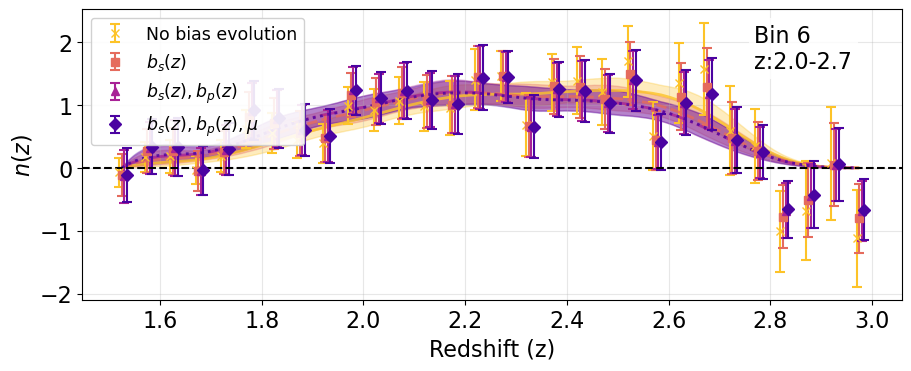

In [57]:
importlib.reload(spline)
s_data = {}
expect = {}
show_knots = False

for tomo in tomo_bins:
    tracers = []
    for tracer in tomo_to_tracer[tomo]:
        if tracer not in tracers:
            tracers.append(tracer)
    tracers = sorted(tracers, key=order.index)
    
    spline_dict = {
        name: spline.BayesianBSpline.from_saved_model(
            f'splines_results/{title}{name}_tracers={",".join(tracers)}_bin={str(tomo)}_scale_cut={scale_cut[0]}-{scale_cut[1]}_{identifier}_{stem}_{hsc_catalog}_{version}'
        )
        for name in names
    }
    tracers = []
    # with pm.make_plot(f"nz_spline_tomo{tomo}", figsize=(9, 3.6), show=True) as (
    #     fig,
    #     ax_main,
    # ):
    
    plt.rcParams.update({'font.size': 16}) #16
    fig, ax = plt.subplots(constrained_layout=True, figsize=(9,3.6)) # 9-3.6
    cmap = plt.get_cmap("plasma_r")
    markers = ["x", "s", "^", "D", "o", "v"]
    linestyles = ["-", "--", "-.", ":", (0, (3, 1, 1, 1)), (0, (5, 1))]

    for ind, name in enumerate(names):
        spl_study = spline_dict[name]

        mask = (z_all <= spl_study.zv.max()) & (z_all >= spl_study.zv.min())
        z_eval = z_all[mask]

        n_eval_points = 200
        nz_samples = spl_study.get_samples(
            z_eval=z_eval, n_eval_points=n_eval_points
        )
        basis_eval = spl_study._create_evaluation_basis(z_eval)

        nz_median = np.percentile(nz_samples, 50, axis=0)
        norm_median = simpson(nz_median, z_eval)
        nz_samples_norm = nz_samples / simpson(nz_samples, z_eval, axis=1)[:, None]

        nz_median = np.percentile(nz_samples_norm, 50, axis=0)
        nz_mean = np.mean(nz_samples_norm, axis=0)
        nz_std = np.std(nz_samples_norm, axis=0)
        nz_lower = np.percentile(nz_samples_norm, 16, axis=0)
        nz_upper = np.percentile(nz_samples_norm, 84, axis=0)

        color = cmap((ind + 0.5) / (len(names)))

        nz_median_all = np.zeros(len(z_all))
        nz_mean_all = np.zeros(len(z_all))
        nz_mean_all[mask] = nz_mean
        nz_median_all[mask] = nz_median
        nz_lower_all = np.zeros(len(z_all))
        nz_lower_all[mask] = nz_lower
        nz_upper_all = np.zeros(len(z_all))
        nz_upper_all[mask] = nz_upper

        s_data[f"z"] = z_all
        if (name == "npz_bs_bp") or (name == "npz_bs_bp_mag"):
            if "mag" in name:
                add = "_mu"
            else:
                add = ""
            s_data[f"{tomo}/nz_median{add}"] = nz_median_all
            s_data[f"{tomo}/nz_mean{add}"] = nz_mean_all
            s_data[f"{tomo}/nz_lower{add}"] = nz_lower_all
            s_data[f"{tomo}/nz_upper{add}"] = nz_upper_all

        ax.errorbar(
            spl_study.zv + (0.005 * (ind - 1)),
            spl_study.nz / norm_median,
            yerr=spl_study.nz_err / norm_median,
            fmt=markers[ind],
            color=color,
            alpha=1,
            capsize=3.5,
            capthick=1.5,
            label=name_to_label[name],
        )
        ax.plot(
            z_eval,
            nz_median,
            color=color,
            alpha=0.8,
            linewidth=2,
            linestyle=linestyles[ind],
        )
        ax.fill_between(
            z_eval,
            nz_lower,
            nz_upper,
            color=color,
            alpha=0.3,
        )
        print("\n")
        print("Expectation")
        expect_samples = [
            np.trapz(nzsn * z_eval, z_eval) for nzsn in nz_samples_norm
        ]
        percentiles = np.percentile(expect_samples, [16, 50, 84])
        print(f"16th, 50th, 84th percentiles: {percentiles}")
        expect_nz = np.trapz(nz_mean * z_eval, z_eval)
        print(f"Expectation from mean n(z): {expect_nz}")
        print("\n")
        expect[f"{tomo}/{name}"] = percentiles
        expect[f"{tomo}/{name}_mean"] = expect_nz

    ax.legend(fontsize=12.5, loc="upper left", framealpha=0.9)
    ax.text(
        0.82,
        0.95,
        f"Bin {tomo}\nz:{hsc_bins[tomo][0]}-{hsc_bins[tomo][1]}",
        transform=ax.transAxes,
        verticalalignment="top",
        bbox=dict(facecolor="white", alpha=0.8, edgecolor="none"),
        fontsize=16,
    )

    if show_knots:
        knot_positions = spl_study.knots[spl_study.degree : -spl_study.degree]
        for i, knot in enumerate(knot_positions):
            alpha_val = 0.6 if i == 0 else 0.4
            label_val = "Knots" if i == 0 else None
            ax.axvline(
                knot,
                color="gray",
                linestyle="--",
                alpha=alpha_val,
                linewidth=1,
                label=label_val,
            )

    ax.set_xlabel("Redshift (z)", fontsize=16)
    ax.set_ylabel(r"$n(z)$", fontsize=16)
    ax.axhline(0, color="black", linestyle="--")
    ax.grid(True, alpha=0.3)
    
    # compute the file name according to parameters
    tracers = []
    order = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
    for tracer in tomo_to_tracer[tomo]:
        if tracer not in tracers:
            tracers.append(tracer)
    tracers = sorted(tracers, key=order.index)

    identifier = f'mocs={"".join(map(str, patches))}_icut={imag_cut}'
    
    suffix = (
    f'{title}nz-fit_tracers={",".join(tracers)}_'
    f'bin={str(tomo)}_scale_cut={scale_cut[0]}-{scale_cut[1]}_'
    f'{identifier}_{stem}_{hsc_catalog}_{version}'
    )
    
    Path('paper_figs').mkdir(parents=True, exist_ok=True)
    plt.savefig(f'paper_figs/{suffix}.png', bbox_inches='tight', dpi=300)
    
    plt.show()

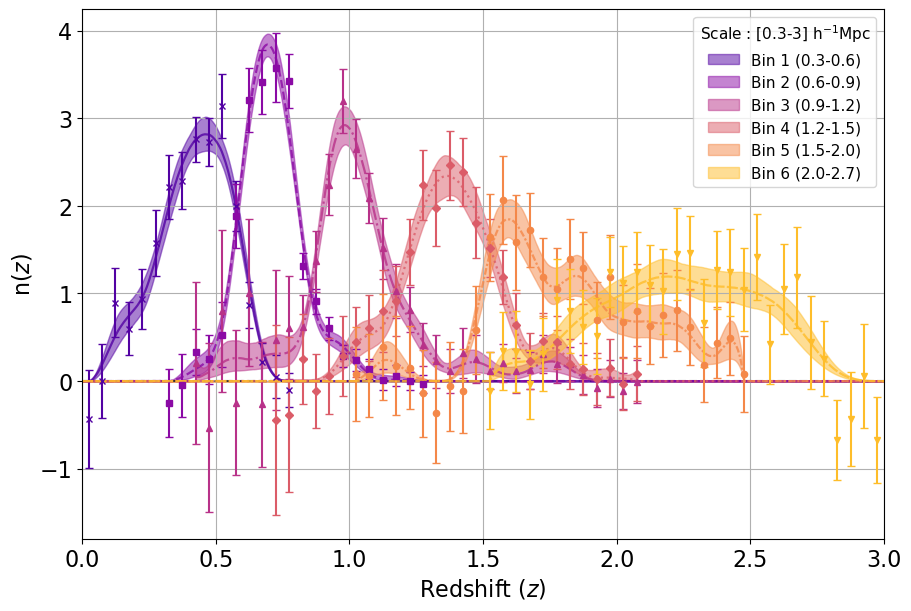

In [58]:
show_dnnz_phot = True

bounds = params['nz_splines']['bounds']
tracers = []
order = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
    
for tomo_bin in tomo_bins:
    for tracer in tomo_to_tracer[tomo_bin]:
        if tracer not in tracers:
            tracers.append(tracer)
tracers = sorted(tracers, key=order.index)

suffix = f'{title}nz_tracers={",".join(tracers)}_bins={"".join(map(str, tomo_bins))}_scale_cut={scale_cut[0]}-{scale_cut[1]}_{identifier}_{stem}_{hsc_catalog}_{version}.npz'
data_file = f'nz_results/{suffix}'
data = np.load(data_file)

plt.rcParams.update({'font.size': 16})
fig, ax = plt.subplots(constrained_layout=True, figsize=(9, 6))
cmap = plt.get_cmap("plasma")
# ax.errorbar(z, npz_raw, yerr=npz_raw_err, fmt='d', color='b', capsize=3, label="No mag correction")
# ax.errorbar(z, npz_mag, yerr=npz_mag_err, fmt='x', color='r', capsize=3, label="With mag correction")
ax.grid(True)
ax.axhline(0, color="black", alpha=0.7, linestyle="--")
ax.set_xlabel(
    r"Redshift ($z$)",
)
ax.set_ylabel(r"n($z$)")
ax.set_xlim(0.0, 3)

username = params['username']
tomo_bin_dnnz = np.loadtxt(f"/global/cfs/projectdirs/desi/users/{username}/desi-y3-hsc/data/pz/tomographic_binning_dnnz.dat")
mids = tomo_bin_dnnz[:, 0]

# for tomo in tomo_bins:
    # dnnz, mu, cov = comb.hsc_dnnz_error(tomo_bin_dnnz[:, tomo], mids)
    # ax.fill_between(
    #     mids,
    #     np.percentile(dnnz, 16, axis=0),
    #     np.percentile(dnnz, 84, axis=0),
    #     color="black",
    #     hatch="//",
    #     alpha=0.2,
    # )
z_eval_full = s_data["z"]

for tomo in tomo_bins:
    nz_median = s_data[f"{tomo}/nz_median_mu"]
    nz_mean = s_data[f"{tomo}/nz_mean_mu"]
    nz_lower = s_data[f"{tomo}/nz_lower_mu"]
    nz_upper = s_data[f"{tomo}/nz_upper_mu"]

    col = cmap((tomo) / (len(tomo_bins)+1))
    ax.plot(
        z_eval_full,
        nz_median,
        color=col,
        alpha=0.8,
        linewidth=1.6,
        linestyle=linestyles[tomo - 1],
    )
    ax.fill_between(
        z_eval_full,
        nz_lower,
        nz_upper,
        color=col,
        alpha=0.5,
    )
    
    z_data = data[f"{tomo}/npz_bs_bp_mag_z"]
    npz_data = data[f"{tomo}/npz_bs_bp_mag"]
    npz_data_err = data[f"{tomo}/npz_bs_bp_mag_err"]
    mask_data = (z_data > bounds[tomo][0]) & (z_data < bounds[tomo][1])

    ax.errorbar(
        z_data[mask_data],
        npz_data[mask_data],
        yerr=npz_data_err[mask_data],
        fmt=markers[tomo - 1],
        color=col,
        capsize=3,
        ms=4.5,
        alpha=1,
    )

    from matplotlib.patches import Patch
    from matplotlib.lines import Line2D

    legend_elements = []
    # legend_elements.append(
    #     Patch(
    #         facecolor="gray", edgecolor="gray", alpha=0.2, hatch="//", label="Phot"
    #     )
    # )
    for tomo in tomo_bins:
        col = cmap((tomo) / (len(tomo_bins)+1))
        legend_elements.append(
            Patch(
                facecolor=col,
                edgecolor=col,
                alpha=0.5,
                label=f"Bin {tomo} ({hsc_bins[tomo][0]}-{hsc_bins[tomo][1]})",
            )
        )
    ax.legend(
        handles=legend_elements,
        loc="upper right",
        frameon=True,
        fontsize=11,
        title=f"Scale : [{scale_cut[0]}-{scale_cut[1]}] " + r"h$^{-1}$Mpc",
        title_fontsize=11,
    )
# ax.legend(title=f'Bin {tomo}\nScale : [0.3-3] '+r'h$^{-1}$Mpc', loc='upper right')
# compute the file name according to parameters

suffix = (
f'{title}fit-nz_tracers={",".join(tracers)}_'
f'bins={"".join(map(str, tomo_bins))}_scale_cut={scale_cut[0]}-{scale_cut[1]}_'
f'{identifier}_{stem}_{hsc_catalog}_{version}'
)

Path('paper_figs').mkdir(parents=True, exist_ok=True)
plt.savefig(f'paper_figs/{suffix}.png', bbox_inches='tight', dpi=300)

plt.show()